### Übung 4 Clustering 1



#### Aufgabe 1 (10)

Verwenden Sie den Weindatensatz aus dem letzten Übungsblatt. 

__a)__ Versuchen Sie das Problem um den unbekannten Wein mit hierarchischem Clustering zu lösen. Clustern Sie auf den skalierten Daten und verwenden Sie die unterschiedlichen Linkagemethoden (‘ward’, ‘complete’, ‘average’, ‘single’)  



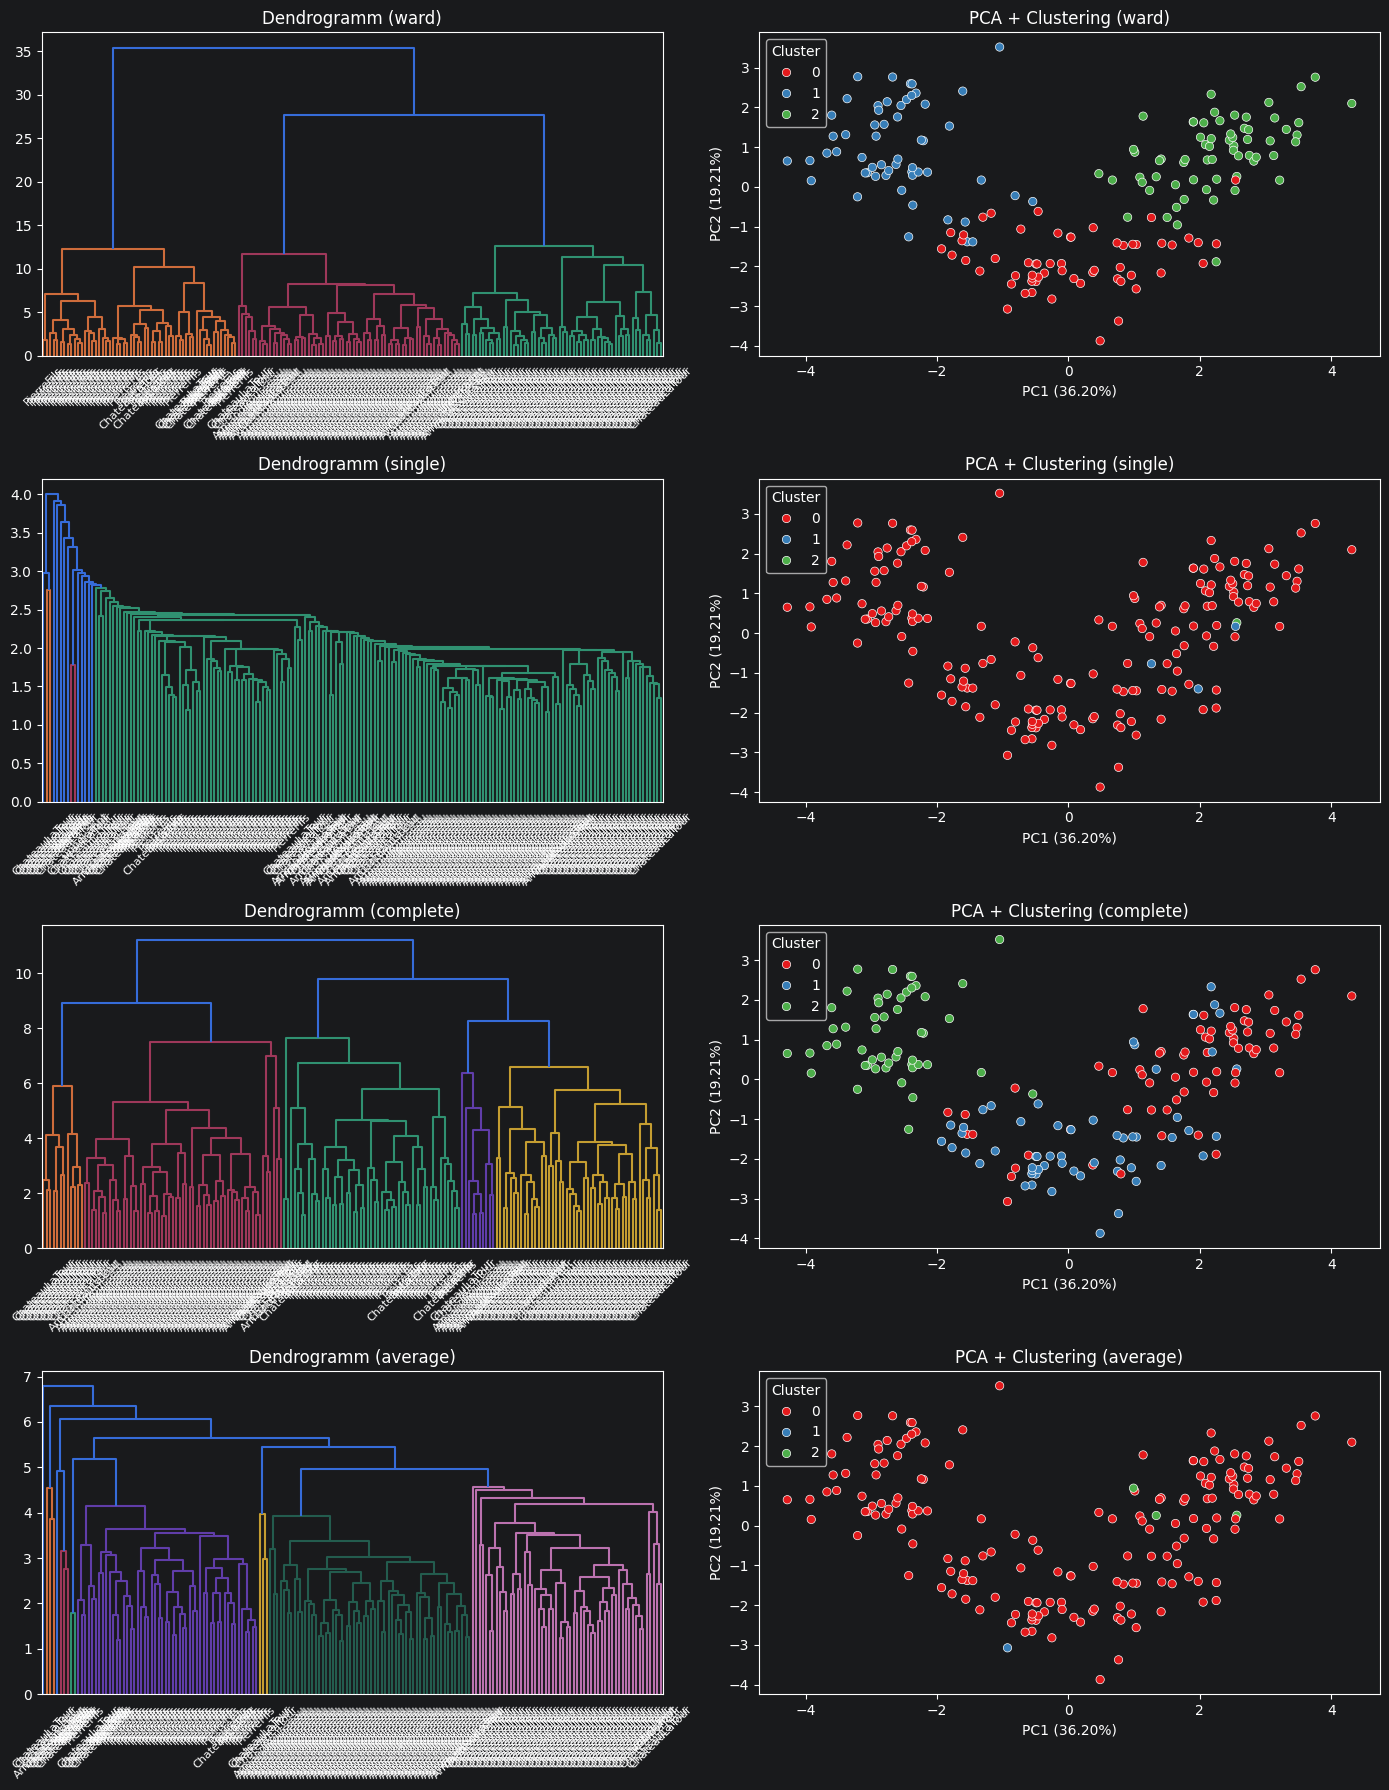

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

wine = pd.read_csv("wine_final.txt", sep=",")

features = wine.drop(columns="Weingut")

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

methods = ["ward", "single", "complete", "average"]

fig, axes = plt.subplots(len(methods), 2, figsize=(14, 18))

# PCA EINMAL berechnen (wichtig!)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

base_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
base_pca["Weingut"] = wine["Weingut"]

for i, method in enumerate(methods):

    # -------------------------
    # CLUSTERING
    # -------------------------
    linkage_matrix = sch.linkage(scaled, method=method)

    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(scaled)

    df_plot = base_pca.copy()
    df_plot["Cluster"] = labels

    # -------------------------
    # DENDROGRAMM
    # -------------------------
    ax1 = axes[i, 0]
    sch.dendrogram(
        linkage_matrix,
        labels=wine["Weingut"].values,
        leaf_rotation=45,
        leaf_font_size=8,
        ax=ax1
    )
    ax1.set_title(f"Dendrogramm ({method})")

    # -------------------------
    # PCA PLOT (CLUSTER VISUALISIERUNG)
    # -------------------------
    ax2 = axes[i, 1]

    sns.scatterplot(
        data=df_plot,
        x="PC1",
        y="PC2",
        hue="Cluster",
        palette="Set1",
        ax=ax2
    )

    ax2.set_title(f"PCA + Clustering ({method})")
    ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
    ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

plt.tight_layout()
plt.show()

[9.98082219e-01 1.73609825e-03 9.69344564e-05 5.16081316e-05
 1.29362242e-05 8.83009021e-06 3.64023763e-06 1.84170418e-06
 1.53690848e-06 1.25495487e-06 1.05762200e-06 6.89806314e-07
 5.98732862e-07 3.22196234e-07 2.06457025e-07 1.45192895e-07
 7.96693079e-08]


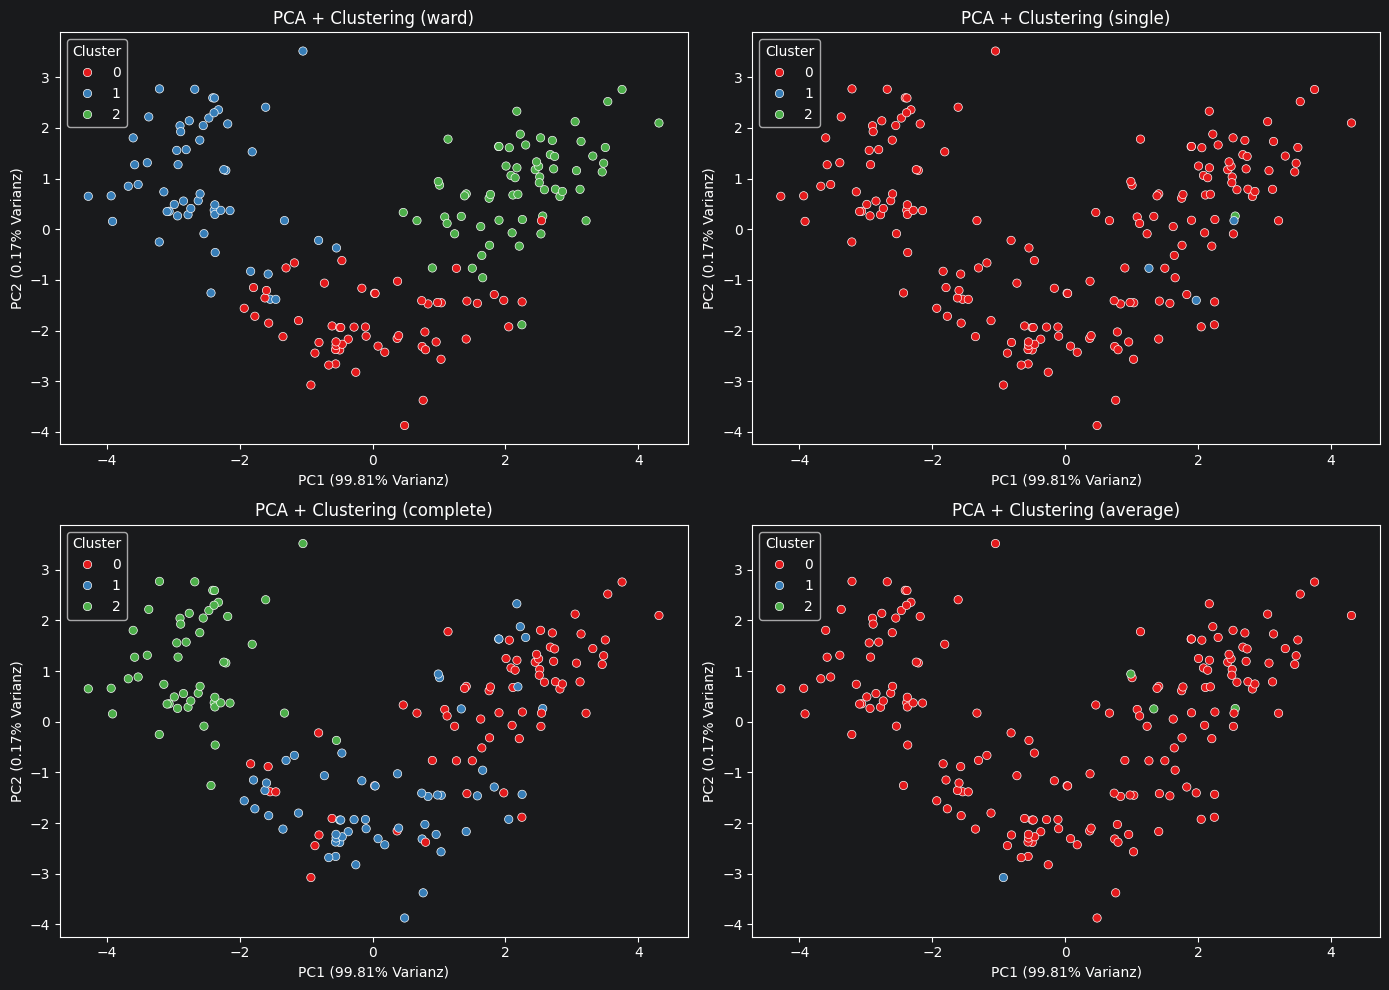

__b)__ Verwenden Sie weiterhin das hierarchische Clustern mit beliebiger Linkage Methode, legen Sie eine sinnvolle Clustergröße fest, clustern Sie die Daten erneut und lassen Sie sich dann die PCA mit den Punkten gefärbt nach Cluster und geformt nach Weingut anzeigen. Erklären Sie das Ergebnis.

#### Aufgabe 2 Mickey Mouse Datensatz (10)

Eine Standardaufgabe für Clusteringalgorithmen besteht darin, 3 Cluster richtig zu trennen. 
Der erste Datensatz ist _clusters3.csv_ und der zweite Datensatz ist _mickeythemouse.csv_. Skalieren Sie die Daten für diese Aufgabe bitte nicht.

__a)__ Lesen Sie beide Datensätze in Python ein und erstellen Sie je einen Scatterplot

__b)__ Wenden sie hierarchisches Clustern auf den ersten (einfachen) Datensatz an. Verwenden Sie immer 3 Cluster und markieren Sie diese farblich in einem Scatterplot. Probieren Sie unterschiedliche Distanzmaße (“euclidean”, “l1”, “l2”, “manhattan”, “cosine”) und Clusterstrategien (‘ward’, ‘complete’, ‘average’, ‘single’) aus.
Bevor Sie starten: Was ist _cosine_, was ist _l1_ und _l2_?

__b)__ Verwenden Sie nun den Mickey Mouse Datensatz mit den Linkage- und Distanzmethoden von oben.

#### Aufgabe 3 Genespressionsdaten von Rauchern (10)

Gegeben sind Ihnen Daten über die Expressionsstärke von Genen, die sich bei Rauchern und Nicht-Rauchern unterscheiden. Sie möchten im Folgenden anhand der Genexpression die Personen (Raucher/Nicht-Raucher) clustern.

__a)__ Lesen Sie die drei Datensätze _GSE4498_series_data.txt_, _metadata.txt_ und _regulatedGenes.txt_ in Python ein. Filtern Sie die Daten der Datei _GSE4498_series_data.txt_, so dass nur noch die Daten zu den Genen übrig bleiben, die in _regulatedGenes.txt_ vorhanden sind.

__b)__ Stellen Sie ein Boxplot über jede Spalte der GSE Daten dar.

__c)__ Führen Sie eine Standardskalierung über die Spalten der GSE Daten durch. Erstellen Sie erneut Boxplots je Spalte. Warum skalieren Sie in diesem Fall über die Spalten und nicht über die Zeilen?

__d)__
Transformieren Sie die GSE-Matrix und fügen Sie eine Spalte mit der Information Raucher/Nicht-Raucher hinzu.

__e)__ Stellen Sie die Daten in einer Dimensionsreduzierten Form (z.B. PCA) dar. Färben Sie die Punkte nach _smoker_ und _non_smoker_

__f)__ Verwenden Sie hierarchisches Clustering und Clustern Sie einmal die "originalen" Daten und einmal die PCA transformierten Daten (mit den ersten beiden Hauptkomponenten). Erstellen Sie je ein Dendrogramm.

__g)__ Erstellen Sie je zwei PCA-Scatterplots, färben Sie die Daten jeweils nach den oben ermittelten Clustern. Wählen Sie als Clusteranzahl zwei aus. Formen Sie die Punkte nach Raucher/Nicht-Raucher.